In [1]:
import numpy               as np
import seaborn             as sns
import pandas              as pd
import libraries.plotting  as slp
import libraries.utilities as sul
import os

sns.set_theme()

/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_i

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
slab_folder = '/Users/cibran/Desktop/SbSBr-alignments'
slab_folder = 'input/ML-slabs/SbSBr'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = sul.read_energy(bulk_folder)

# Load bulk information
slab_data = sul.load_json(filename=f'{bulk_folder}/slab_data.json')

n_bulk = slab_data['number_of_sites']

Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

In [4]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, miller_index_str in enumerate(os.listdir(slab_folder)):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'

    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load slab information
    slab_data = sul.load_json(filename=f'{miller_folder}/slab_data.json')

    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab_data['miller_index']}')
    print(f'Shift: {slab_data['shift']:.3g}')
    print(f'Surface area: {slab_data['surface_area']:.3g}')
    print(f'Number of sites: {slab_data['number_of_sites']}')

    # Load the single-shot energy
    slab_energy = sul.read_energy(miller_folder)

    print(f'E_total = {slab_energy:.3g} eV')

    bulk_energy_times_fu = bulk_energy * slab_data['number_of_sites'] / n_bulk
    
    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(slab_energy, bulk_energy_times_fu, slab_data['surface_area'])

    # Load the slab energy
    np.savetxt(f'{miller_folder}/surface_energy_of_formation', [surface_energy_of_formation])

    print(f'\t$E_surface$ = {surface_energy_of_formation:.3g} J/m²')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])


Slab 1

Miller index: [2, 1, 2]
Shift: 0.25
Surface area: 198
Number of sites: 144
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

E_total = -526 eV
	$E_surface$ = 0.248 J/m²

Slab 2

Miller index: [0, 0, 1]
Shift: 0.163
Surface area: 34
Number of sites: 24
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

E_total = -88.5 eV
	$E_surface$ = 0.0607 J/m²

Slab 3

Miller index: [1, 1, 1]
Shift: 1.24e-14
Surface area: 106
Number of sites: 72
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


...

/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

E_total = -261 eV
	$E_surface$ = 0.434 J/m²

Slab 86

Miller index: [0, 1, 0]
Shift: 0.5
Surface area: 41.8
Number of sites: 36
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
E_total = -130 eV
	$E_surface$ = 0.507 J/m²

Slab 87

Miller index: [2, 0, 1]
Shift: 2.98e-14
Surface area: 185
Number of sites: 144
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

E_total = -531 eV
	$E_surface$ = 0.0642 J/m²

Slab 88

Miller index: [0, 0, 1]
Shift: 0.25
Surface area: 34
Number of sites: 24
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
E_total = -87.5 eV
	$E_surface$ = 0.281 J/m²


/home/claudio/cibran/Work/UPC/SlabOptimization/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mo

# Extract local minimas and generate input files

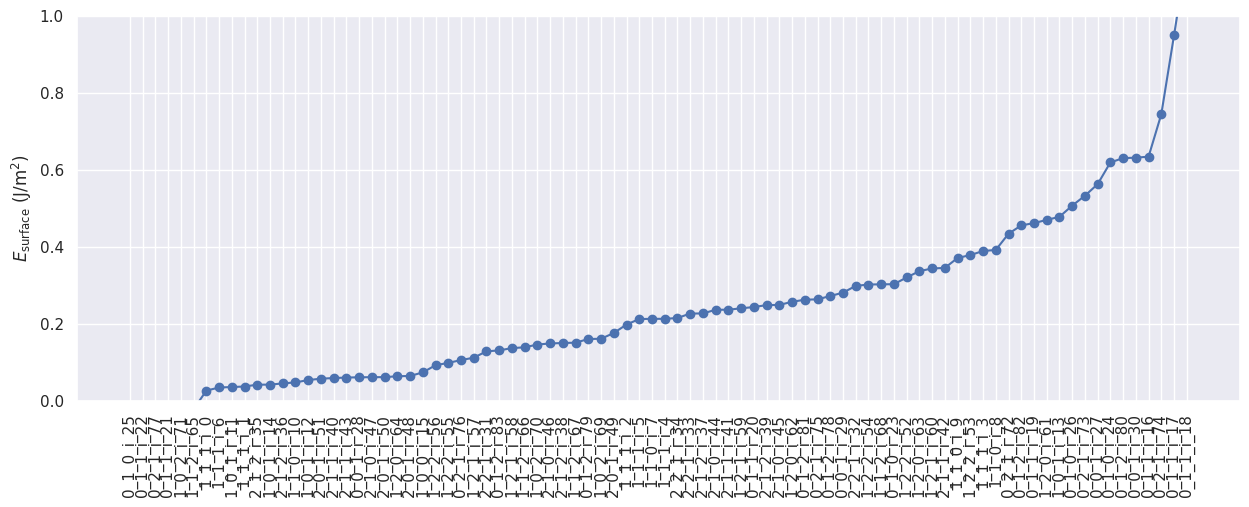

In [5]:
slp.plot_ranking(surface_energies_of_formation,
                 ylabel=r'$E_{\text{surface}}$ (J/m$^2$)',
                 filename=f'{slab_folder}/ranking.png', dpi=300)